# Preparation

## 1. Importing libraries and files

In [5]:
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import json

pd.options.display.float_format = '{:.2f}'.format
print("OK")

OK


In [2]:
main_dir = "../.."
raw_data = pd.read_csv(f"{main_dir}/data/raw/raw_dataset.csv")
dataset = pd.read_csv(f"{main_dir}/data/clean_dataset.csv")
cords = pd.read_csv(f"{main_dir}/data/external/cords.csv", dtype={"xcords":str, "ycords":str})
with open(f"{main_dir}/data/external/be.json") as f:
    be = json.load(f)
    f.close()
colors = {"color1": "#127FC3",
          "color2": "#F2D544",
          "color3": "#EB5700",
          "color4": "#1A9988",
          "facecolor": "#E9EDEE",
          "facecolor2": "#CCCFD0",
          "facecolor3": "#B0B3B4"
}
cmap = mcolors.LinearSegmentedColormap.from_list(
    "proj_density",
    ["#424C52", "#6F92A7", "#127FC3"]
)
print("OK")

OK


## Raw dataset

In [23]:
raw_data.isna().sum()

Locality                     0
Type of property             0
Subtype of property          0
Price                      513
Number of rooms            541
Living Area               1773
Terrace Area             16413
Garden Area              21076
Surface of the land      13331
Number of facades         6305
State of the building     6113
Furnished                    0
Terrace                      0
Garden                       0
Swimming pool                0
dtype: int64

There is a lot data to clean.
- We may remove terace area and garder area because these fields almost empty. Also we have boolean value about these parameters.
- State of building was changed to numbers.
- Priceless rows removed
- Surface of the land was filled with 0 when NA for appartments
- Locality cleaned and changed to Region + Municipality
- Created indexing of rows. We prevent duplicates in data, so all properties are unique even if looks same
- All collumns renamed for friendly coding.

In [44]:
dataset.head()

,index,type,subtype,price,living_area,land_area,facades,state,furnished,terrace,garden,pool,region,municipality
0,0,house,residence,90000,120,235,2,2,False,True,True,False,Walloon Region,Chièvres
1,1,apartment,apartment,90000,49,0,2,6,False,True,False,False,Walloon Region,Charleroi
2,2,house,residence,90000,165,1410,4,2,False,False,True,False,Walloon Region,Frasnes-lez-Anvaing
3,3,house,residence,90000,115,269,2,2,False,True,False,False,Walloon Region,Dour
4,4,house,residence,90000,113,170,2,2,False,True,True,False,Walloon Region,Dour


## Removing number of rooms

In [110]:
rooms = dataset.iloc[100:-100,3:6]
rooms.price = rooms.price.apply(lambda x: round(x / 100000) * 100000)
rooms = rooms.groupby("price").mean().reset_index()
print("Correlation between Living area and Number of rooms is: ",
      rooms.corr().iloc[1,2] * 100 // 1 / 100, sep = "")

Correlation between Living area and Number of rooms is: 0.95


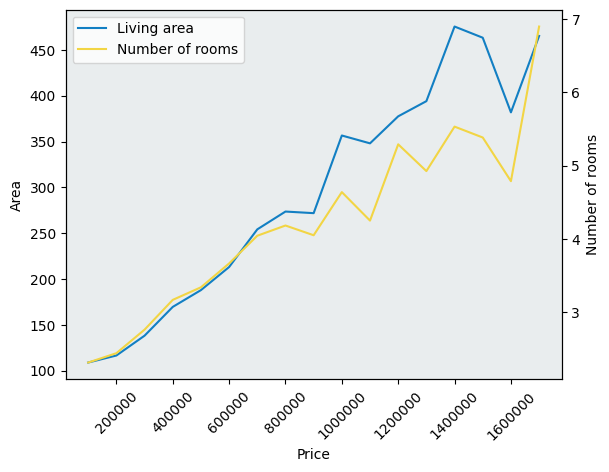

In [111]:
fig, ax = plt.subplots()
l1, = ax.plot(rooms.price, rooms.living_area, color = colors["color1"], label = "Living area")
ax2 = ax.twinx()
l2, = ax2.plot(rooms.price, rooms["Number of rooms"], color = colors["color2"], label = "Number of rooms")
ax.legend(handles = [l1, l2])
ax.set_xlabel("Price")
ax.ticklabel_format(style="plain", axis = "x")
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Area")
ax2.set_ylabel("Number of rooms")
ax.set_facecolor(color = colors["facecolor"])
plt.show()
fig.savefig("plots/number_of_rooms.png", bbox_inches="tight")

For this reason Number of rooms was removed from data. Because as price depended on Living area - it is same way depended on Number of rooms.

# Analysis

## Correlation

In [7]:
corr_house = dataset[dataset.type == "house"].corr(numeric_only = True)["price"].to_frame()
corr_apartment = dataset[dataset.type == "apartment"].corr(numeric_only = True)["price"].to_frame()
corr_house = corr_house.rename(columns = {"price": "house"})
corr_apartment = corr_apartment.rename(columns = {"price": "apartment"})
corr = corr_house.T.merge(corr_apartment.T, how ="outer")
corr = corr.T.rename(columns = {0: "house", 1: "apartment"})[2:]
corr

,house,apartment
living_area,0.59,0.59
land_area,0.30,NaN
facades,0.29,0.07
state,0.24,0.33
furnished,0.05,0.00
terrace,0.11,0.23
garden,0.08,0.12
pool,0.32,0.05


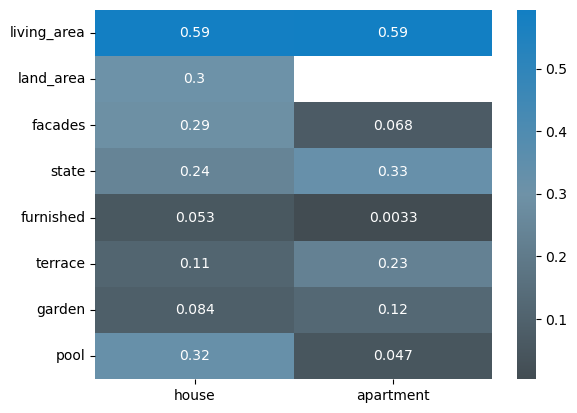

In [11]:
fig, ax = plt.subplots()
sns.heatmap(corr, annot= True, cmap = cmap)
plt.show()
fig.savefig("plots/correlation_price.png", bbox_inches="tight")

## Living area to Price ratio

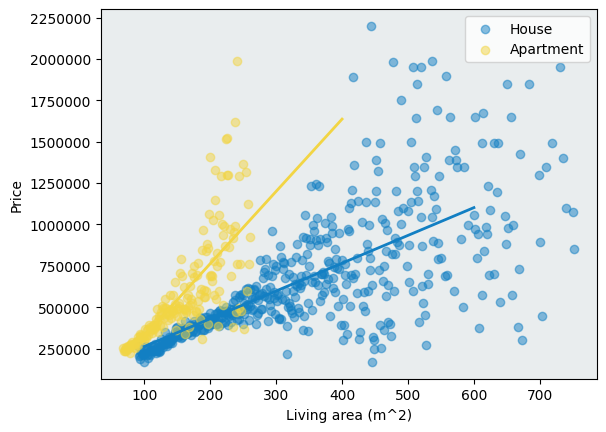

In [94]:
house_living_area = dataset[dataset.type == "house"].groupby("living_area")["price"].mean().to_frame().reset_index().iloc[50:-50]
apartment_living_area = dataset[dataset.type == "apartment"].groupby("living_area")["price"].mean().to_frame().reset_index().iloc[50:-50]
fig, ax = plt.subplots()
ax.scatter(house_living_area.living_area, house_living_area.price, color=colors["color1"], alpha = .5)
ax.scatter(apartment_living_area.living_area, apartment_living_area.price, color=colors["color2"], alpha = .5)
line_house = np.poly1d(np.polyfit(house_living_area.living_area, house_living_area.price, 1))
line_apartment = np.poly1d(np.polyfit(apartment_living_area.living_area, apartment_living_area.price, 1))
line_xrange_house = np.linspace(100, 600)
line_xrange_apartment = np.linspace(100, 400)
ax.plot(line_xrange_house, line_house(line_xrange_house), color=colors["color1"], lw=2)
ax.plot(line_xrange_apartment, line_apartment(line_xrange_apartment), color=colors["color2"], lw=2)

ax.legend(["House", "Apartment"])
ax.set_xlabel("Living area (m^2)")
ax.set_ylabel("Price")
ax.ticklabel_format(style='plain', axis='y')
ax.set_facecolor(colors["facecolor"])
plt.show()
fig.savefig("plots/living_area_to_price.png", bbox_inches="tight")

In [46]:
dataset[dataset.type == "apartment"].sort_values("living_area", ascending = False).iloc[10:,1:5].head(10)

,type,subtype,price,living_area
13734,apartment,apartment,895000,444
12486,apartment,apartment,595000,430
14012,apartment,apartment,1100000,429
12644,apartment,apartment,610000,403
14210,apartment,duplex,1390000,399
11015,apartment,apartment,480000,380
13946,apartment,apartment,998800,376
13947,apartment,penthouse,999000,370
14023,apartment,apartment,1125000,368
13469,apartment,loft,795000,365


In [42]:
print("Correlation between Living area and Price for houses is: ",
      house_living_area.corr().iloc[0, 1] * 100 // 1 / 100, sep = "")
print("Correlation between Living area and Price for apartments is: ",
      apartment_living_area.corr().iloc[0, 1] * 100 // 1 / 100, sep = "")

Correlation between Living area and Price for houses is: 0.7
Correlation between Living area and Price for apartments is: 0.74


## Price based on Subtype

Checking if **STD** is lower than **MEAN**.

In [17]:
temp = dataset.groupby("subtype")["price"].agg(["std", "mean"])
temp.iloc[:,:]
temp

,std,mean
subtype,,
apartment,213127.33,339361.34
bungalow,118409.25,342454.55
chalet,109047.98,232887.10
cottage,319355.61,547416.05
duplex,227636.91,380773.80
ground-floor,190489.42,333665.01
loft,292508.40,494618.40
mansion,436643.04,1237500.00
master-house,433594.17,688747.46


Results: **STD** gives lower values than **MEAN**. So we can use **MEAN** to create Bar Chart for Subtypes and Prices.

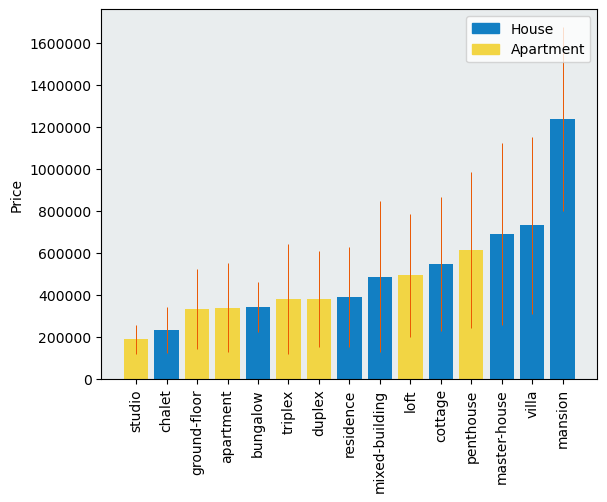

In [30]:
subtypes = dataset.groupby(["type", "subtype"])["price"].agg(["mean", "std"]).reset_index().sort_values("mean")
subtypes["color"] = subtypes["type"].apply(lambda x: colors["color1"] if x == "house" else colors["color2"])
legend = [
    Patch(color=colors["color1"], label = "House"),
    Patch(color=colors["color2"], label = "Apartment")
]
fig, ax = plt.subplots()
ax.bar(subtypes.subtype, subtypes["mean"], color=subtypes.color, 
       yerr = subtypes["std"], ecolor = colors["color3"], error_kw={"elinewidth": 0.7})
ax.legend(handles = legend)
ax.set_ylabel("Price")
ax.ticklabel_format(style="plain", axis="y")
ax.set_facecolor(colors["facecolor"])
plt.xticks(rotation=90)
plt.show()
fig.savefig("plots/house_type.png", bbox_inches="tight")

## Locality

In [35]:
# based on mean
loc = dataset[["type", "price", "region", "municipality", "living_area"]]
mun = {}
for i, line in cords.iterrows():
    mun[line["municipality"]] = [float(line["xcords"]), float(line["ycords"])]
loc = loc[loc['municipality'].isin(mun.keys())]
loc_w = loc[loc.region == "Walloon Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")
loc_f = loc[loc.region == "Flemish Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")
loc_b = loc[loc.region == "Brussels-Capital Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")

In [31]:
# based on price per m^2
loc = dataset[["type", "price", "region", "municipality", "living_area"]]
mun = {}
for i, line in cords.iterrows():
    mun[line["municipality"]] = [float(line["xcords"]), float(line["ycords"])]
loc.price = loc.price / loc.living_area
loc_w = loc[loc.region == "Walloon Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")
loc_f = loc[loc.region == "Flemish Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")
loc_b = loc[loc.region == "Brussels-Capital Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")

In [36]:
high_w = loc_w.tail(15)["municipality"].to_list()
low_w = loc_w.head(15)["municipality"].to_list()
high_f = loc_f.tail(15)["municipality"].to_list()
low_f = loc_f.head(15)["municipality"].to_list()
high_b = loc_b.tail(7)["municipality"].to_list()
low_b = loc_b.head(7)["municipality"].to_list()

In [39]:
loc_w

,municipality,price
189,Plombières,158000.00
115,Herbeumont,169000.00
193,Quaregnon,169600.00
54,Colfontaine,172641.94
82,Farciennes,182452.82
...,...,...
5,Anhée,704319.20
87,Flobecq,715600.00
178,Onhaye,730750.00
136,Lasne,776667.09


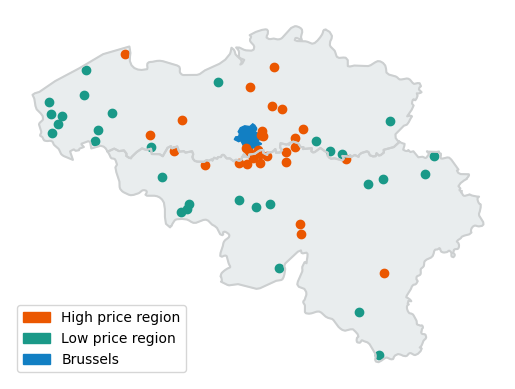

In [117]:
# based on mean price
fig, ax = plt.subplots()

f_cords = be["features"][1]["geometry"]["coordinates"][0][0]
xs = [p[0] for p in f_cords]
ys = [p[1] for p in f_cords]
ax.fill(xs, ys, color=colors["facecolor"])
ax.plot(xs, ys, color=colors["facecolor2"])
w_cords = be["features"][2]["geometry"]["coordinates"][0][0]
xs = [p[0] for p in w_cords]
ys = [p[1] for p in w_cords]
ax.fill(xs, ys, color=colors["facecolor"])
ax.plot(xs, ys, color=colors["facecolor2"])
b_cords = be["features"][0]["geometry"]["coordinates"][0]
xs = [p[0] for p in b_cords]
ys = [p[1] for p in b_cords]
ax.fill(xs, ys, color=colors["color1"])

for value in high_w:
    ax.scatter(mun[value][1], mun[value][0], color = colors["color3"])
for value in high_f:
    ax.scatter(mun[value][1], mun[value][0], color = colors["color3"])
for value in low_w:
    ax.scatter(mun[value][1], mun[value][0], color = colors["color4"])
for value in low_f:
    ax.scatter(mun[value][1], mun[value][0], color = colors["color4"])
legend = [
    Patch(color=colors["color3"], label = "High price region"),
    Patch(color=colors["color4"], label = "Low price region"),
    Patch(color=colors["color1"], label = "Brussels")
]
ax.legend(handles = legend)
ax.axis("off")
plt.show()
fig.savefig("plots/high_low_price_regions.png", bbox_inches="tight")

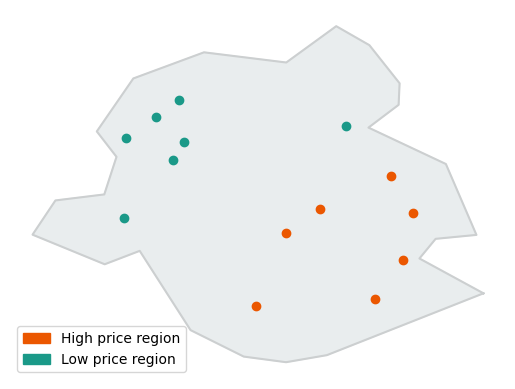

In [118]:
# based on mean price
fig, ax = plt.subplots()

b_cords = be["features"][0]["geometry"]["coordinates"][0]
xs = [p[0] for p in b_cords]
ys = [p[1] for p in b_cords]
ax.fill(xs, ys, color=colors["facecolor"])
ax.plot(xs, ys, color=colors["facecolor2"])

for value in high_b:
    ax.scatter(mun[value][1], mun[value][0], color = colors["color3"])
for value in low_b:
    ax.scatter(mun[value][1], mun[value][0], color = colors["color4"])
legend = [
    Patch(color=colors["color3"], label = "High price region"),
    Patch(color=colors["color4"], label = "Low price region")
]
ax.legend(handles = legend)
ax.axis("off")
plt.show()
fig.savefig("plots/high_low_price_brussels.png", bbox_inches="tight")

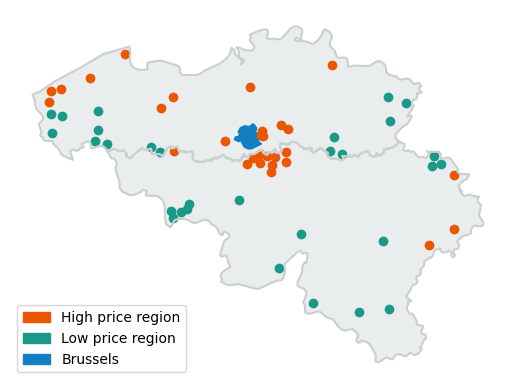

In [50]:
# based on price per m^2
fig, ax = plt.subplots()

f_cords = be["features"][1]["geometry"]["coordinates"][0][0]
xs = [p[0] for p in f_cords]
ys = [p[1] for p in f_cords]
ax.fill(xs, ys, color=colors["facecolor"])
ax.plot(xs, ys, color=colors["facecolor2"])
w_cords = be["features"][2]["geometry"]["coordinates"][0][0]
xs = [p[0] for p in w_cords]
ys = [p[1] for p in w_cords]
ax.fill(xs, ys, color=colors["facecolor"])
ax.plot(xs, ys, color=colors["facecolor2"])
b_cords = be["features"][0]["geometry"]["coordinates"][0]
xs = [p[0] for p in b_cords]
ys = [p[1] for p in b_cords]
ax.fill(xs, ys, color=colors["color1"])

for value in high_w:
    if (value not in mun):
        continue
    ax.scatter(mun[value][1], mun[value][0], color = colors["color3"])
for value in high_f:
    if (value not in mun):
        continue
    ax.scatter(mun[value][1], mun[value][0], color = colors["color3"])
for value in low_w:
    if (value not in mun):
        continue
    ax.scatter(mun[value][1], mun[value][0], color = colors["color4"])
for value in low_f:
    if (value not in mun):
        continue
    ax.scatter(mun[value][1], mun[value][0], color = colors["color4"])
legend = [
    Patch(color=colors["color3"], label = "High price region"),
    Patch(color=colors["color4"], label = "Low price region"),
    Patch(color=colors["color1"], label = "Brussels")
]
ax.legend(handles = legend)
ax.axis("off")
plt.show()
fig.savefig("plots/high_low_price_mm_regions.png", bbox_inches="tight")

In [42]:
for value in high_w:
    print(value)

Chaumont-Gistoux
Enghien
Braine-le-Château
Braine-l’Alleud
Rixensart
Grez-Doiceau
La Hulpe
Waterloo
Berloz
Beauvechain
Anhée
Flobecq
Onhaye
Lasne
Sainte-Ode


In [87]:
for value in low_w[:5]:
    print(value)

Plombières
Herbeumont
Quaregnon
Colfontaine
Farciennes


In [88]:
for value in high_f[:5]:
    print(value)

Linkebeek
Schilde
Oosterzele
Wezembeek-Oppem
Zaventem


In [89]:
for value in low_f[:5]:
    print(value)

Lo-Reninge
Moorslede
Poperinge
Vleteren
Wervik


In [45]:
for value in high_b:
    print(value)

Auderghem
Woluwe-Saint-Lambert
Etterbeek
Watermael-Boitsfort
Ixelles
Uccle
Woluwe-Saint-Pierre


In [91]:
for value in low_b[:5]:
    print(value)

Molenbeek-Saint-Jean
Koekelberg
Jette
Ganshoren
Anderlecht


## State of building

In [101]:
state_house = dataset[dataset.type == "house"].groupby("state")["price"].agg(["std", "mean"]).reset_index()
state_apartment = dataset[dataset.type == "apartment"].groupby("state")["price"].agg(["std", "mean"]).reset_index()
def replace_state(x):
    match x:
        case 2:
            return "To renovate"
        case 4:
            return "Normal"
        case 6:
            return "Renovated"
        case 7:
            return "Excellent"
        case 8:
            return "New"

In [102]:
print("Correlation between State of building and Price for houses is: ",
      state_house[["state","mean"]].corr().iloc[0, 1] * 100 // 1 / 100, sep = "")
print("Correlation between State of building and Price for apartments is: ",
      state_apartment[["state","mean"]].corr().iloc[0, 1] * 100 // 1 / 100, sep = "")

Correlation between State of building and Price for houses is: 0.71
Correlation between State of building and Price for apartments is: 0.97


In [103]:
state_house["state"] = state_house["state"].apply(replace_state)
state_apartment["state"] = state_apartment["state"].apply(replace_state)

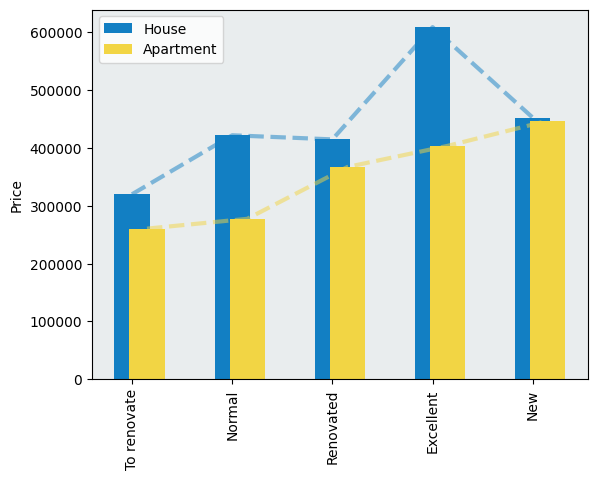

In [104]:
x = np.arange(5)
width = 0.35
fig, ax = plt.subplots()
ax.bar(x, state_house["mean"], width, color=colors["color1"], label='House')
ax.plot(x, state_house["mean"], width, color=colors["color1"], lw=3, linestyle="--", alpha = 0.5)
ax.bar(x+0.15, state_apartment["mean"], width, color=colors["color2"], label='Apartment')
ax.plot(x+0.15, state_apartment["mean"], width, color=colors["color2"], lw=3, linestyle="--", alpha = 0.5)

plt.xticks(x, state_house.state, rotation=90)
ax.set_ylabel("Price")
ax.legend(loc = "upper left")
ax.set_facecolor(colors["facecolor"])
plt.show()
fig.savefig("plots/state_to_price.png", bbox_inches="tight")

## Facades

In [105]:
facades_house = dataset[dataset.type == "house"].groupby("facades")["price"].agg(["std", "mean"]).reset_index()
facades_apartment = dataset[dataset.type == "apartment"].groupby("facades")["price"].agg(["std", "mean"]).reset_index()

In [106]:
print("Correlation between Facades number and Price for houses is: ",
      facades_house[["facades","mean"]].corr().iloc[0, 1] * 100 // 1 / 100, sep = "")
print("Correlation between Facades number and Price for apartments is: ",
      facades_apartment[["facades","mean"]].corr().iloc[0, 1] * 100 // 1 / 100, sep = "")

Correlation between Facades number and Price for houses is: 0.96
Correlation between Facades number and Price for apartments is: 0.9


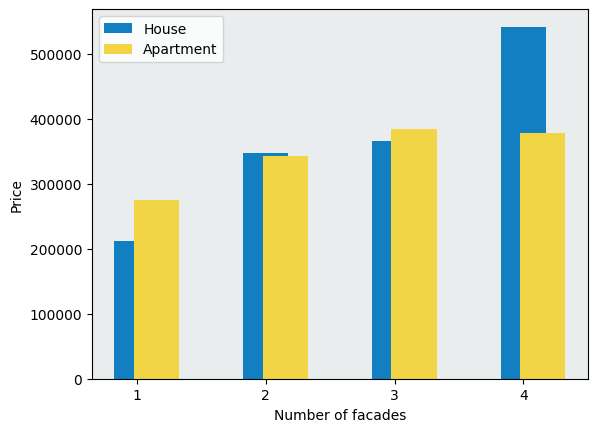

In [107]:
width = 0.35
fig, ax = plt.subplots()
ax.bar(facades_house.facades, facades_house["mean"], width, color=colors["color1"], label='House')
ax.bar(facades_apartment.facades+0.15, facades_apartment["mean"], width, color=colors["color2"], label='Apartment')
plt.xticks([1, 2, 3, 4])

ax.set_ylabel("Price")
ax.set_xlabel("Number of facades")
ax.legend(loc = "upper left")
ax.set_facecolor(colors["facecolor"])
plt.show()
fig.savefig("plots/facades_to_price.png", bbox_inches="tight")

## Land area for houses

In [35]:
land = dataset[dataset.type == "house"][["region", "municipality", "price", "land_area"]]
land = land[(land.land_area > 0) & (land.land_area < 15000)].sort_values("land_area")[100:-100]

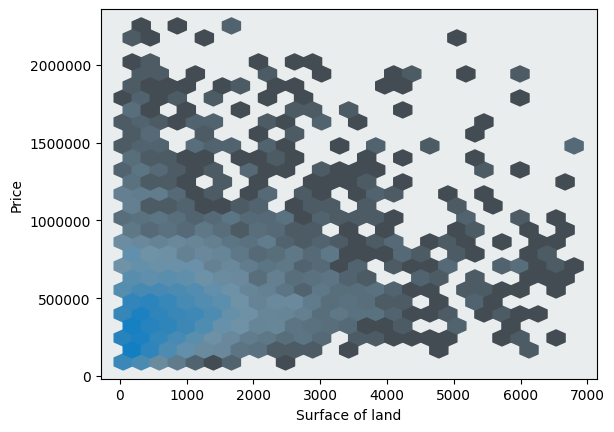

In [36]:
fig, ax = plt.subplots()
ax.hexbin(land.land_area, land.price, gridsize=25, bins='log', cmap=cmap)
ax.set_xlabel("Surface of land")
ax.set_ylabel("Price")
ax.ticklabel_format(style="plain", axis="y")
ax.set_facecolor(colors["facecolor"])
plt.show()
fig.savefig("plots/land_area_to_price.png", bbox_inches="tight")

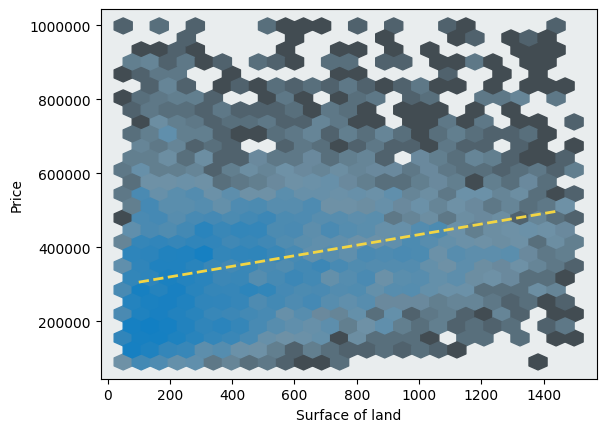

In [34]:
land = land[(land.price < 1000000) & (land.land_area < 1500)]
fig, ax = plt.subplots()
ax.hexbin(land.land_area, land.price, gridsize=25, bins='log', cmap=cmap)
line = np.poly1d(np.polyfit(land.land_area, land.price, 1))
line_xrange = np.linspace(100, 1450)
ax.plot(line_xrange, line(line_xrange), color=colors["color2"], lw=2, linestyle="--")
ax.set_xlabel("Surface of land")
ax.set_ylabel("Price")
ax.ticklabel_format(style="plain", axis="y")
ax.set_facecolor(colors["facecolor"])
plt.show()
fig.savefig("plots/land_area_to_price(small).png", bbox_inches="tight")

In [17]:
land_corr = land.groupby("land_area")["price"].mean().reset_index().corr()
print("Correlation between Land area and Price for houses is: ",
      land_corr.iloc[0, 1] * 100 // 1 / 100, sep = "")

Correlation between Land area and Price for houses is: 0.42
